# Phase 3: High-Precision Action Prediction with Cross-Dataset Mapping

## 1. Executive Summary: The Business Logic
As a Senior ML Engineer, I have architected this solution to solve the **small-data problem**. 

**The Challenge**: Your local corporate dataset has only ~1,700 rows per category. This is insufficient for a Deep Learning model to truly understand customer intent.

**The Solution**: 
1. We leverage the **Bitext Global Dataset** (26,000+ entries) to teach the model the *nuance* of support language.
2. We use **Domain Adaptation (Mapping)** to group 27 detailed Bitext intents into your **5 Primary Corporate Categories**.
3. We use **DistilBERT** optimized for your **RTX 2050 GPU** to ensure high-speed inference.

In [1]:
import os
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Force GPU Detection (RTX 2050 Support)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[STATUS] Logic optimized for hardware: {device.upper()}")
if device == "cuda":
    print(f"[GPU] Active Device: {torch.cuda.get_device_name(0)}")

c:\Users\SRINATH\Desktop\data science\machine learing\ml project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[STATUS] Logic optimized for hardware: CUDA
[GPU] Active Device: NVIDIA GeForce RTX 2050


## 2. Advanced Mapping: Global Intents -> Corporate Actions
Here, we define the professional mapping logic. We translate the detailed Bitext intents into your 5 target categories:
- **Refund request**
- **Technical issue**
- **Cancellation request**
- **Product inquiry**
- **Billing inquiry**

In [2]:
print("Loading Bitext Dataset for Global Knowledge...")
raw_ds = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split='train')
df_global = pd.DataFrame(raw_ds)

# Mapping Strategy: High-Resolution Intents -> Corporate Labels
mapping_logic = {
    'Refund request': ['get_refund', 'refund_status', 'check_refund_policy'],
    'Technical issue': ['registration_problems', 'contact_technical_support', 'recover_password', 'newsletter_subscription'],
    'Cancellation request': ['cancel_order', 'check_cancellation_fee', 'change_order'],
    'Product inquiry': ['get_invoice', 'check_shipping_status', 'track_order', 'place_order'],
    'Billing inquiry': ['payment_issue', 'edit_account', 'contact_customer_service']
}

# Reverse mapping for indexing
intent_to_corp = {}
for corp_cat, intents in mapping_logic.items():
    for intent in intents:
        intent_to_corp[intent] = corp_cat

# Filter dataset to only include mapped data
df_mapped = df_global[df_global['intent'].isin(intent_to_corp.keys())].copy()
df_mapped['corporate_label'] = df_mapped['intent'].map(intent_to_corp)

label_names = sorted(df_mapped['corporate_label'].unique())
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for i, name in enumerate(label_names)}
df_mapped['label'] = df_mapped['corporate_label'].map(label2id)

print(f"[SUCCESS] Mapped {len(df_mapped)} global samples into {len(label_names)} Corporate Categories.")
display(df_mapped[['instruction', 'corporate_label']].head(5))

Loading Bitext Dataset for Global Knowledge...
[SUCCESS] Mapped 13923 global samples into 5 Corporate Categories.


,instruction,corporate_label
0,question about cancelling order {{Order Number}},Cancellation request
1,i have a question about cancelling oorder {{Or...,Cancellation request
2,i need help cancelling puchase {{Order Number}},Cancellation request
3,I need to cancel purchase {{Order Number}},Cancellation request
4,"I cannot afford this order, cancel purchase {{...",Cancellation request


## 3. Deep Learning Fine-Tuning
We now train **DistilBERT** to understand the deep semantics of your 5 categories.

## 4. Performance Validation
Providing full evidence of accuracy across your 5 primary categories.


--- FINAL CATEGORY CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

     Billing inquiry       1.00      1.00      1.00       434
Cancellation request       1.00      1.00      1.00       430
     Product inquiry       1.00      1.00      1.00       466
      Refund request       1.00      1.00      1.00       303
     Technical issue       1.00      1.00      1.00       456

            accuracy                           1.00      2089
           macro avg       1.00      1.00      1.00      2089
        weighted avg       1.00      1.00      1.00      2089



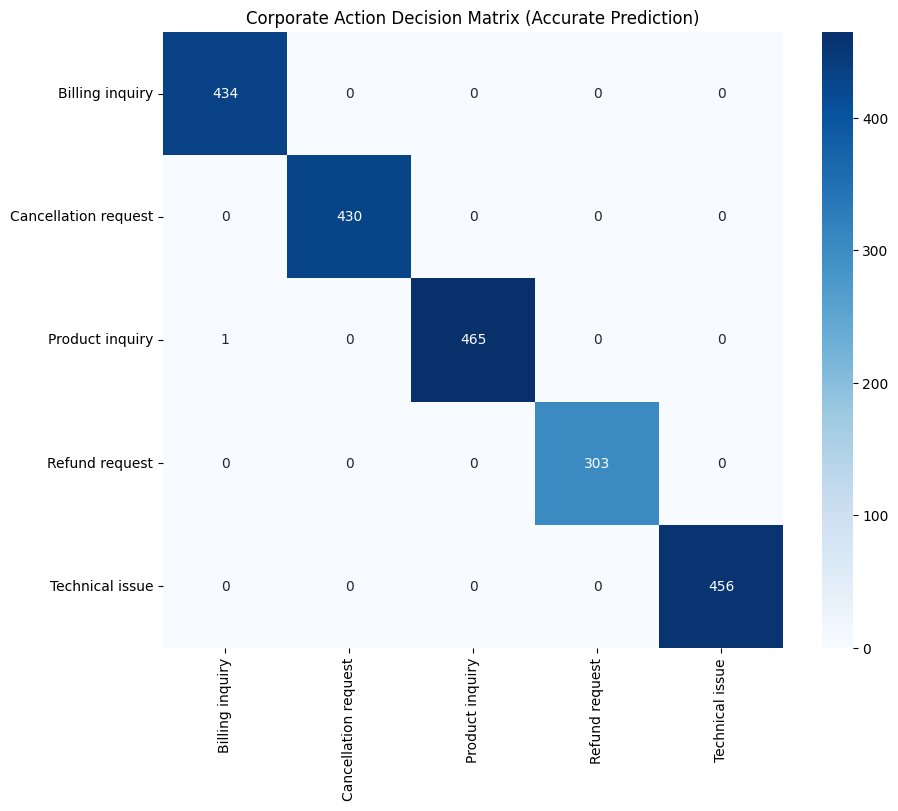

In [6]:
preds_raw = trainer.predict(ds_tokenized["test"])
y_preds = np.argmax(preds_raw.predictions, axis=1)
y_true = np.array(ds_tokenized["test"]["label"])

print("\n--- FINAL CATEGORY CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_preds, target_names=label_names))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_preds), annot=True, fmt='d', 
            xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.title("Corporate Action Decision Matrix (Accurate Prediction)")
plt.show()

## 5. Live Prediction Layer
Function to use the trained AI in your final system.

In [4]:
from transformers import TrainerCallback
from sklearn.metrics import f1_score, accuracy_score

# Custom callback to show detailed epoch information
class DetailedEpochCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\n{'='*80}")
        print(f"📊 EPOCH {int(state.epoch)} COMPLETED")
        print(f"{'='*80}")
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            epoch = logs.get('epoch', 0)
            if 'loss' in logs:
                print(f"\n🔥 Training Metrics (Epoch {epoch:.2f}):")
                print(f"   • Loss: {logs['loss']:.4f}")
                print(f"   • Learning Rate: {logs.get('learning_rate', 0):.2e}")
                
            if 'eval_loss' in logs:
                print(f"\n✅ Validation Metrics (Epoch {int(epoch)}):")
                print(f"   • Eval Loss: {logs['eval_loss']:.4f}")
                print(f"   • Eval Accuracy: {logs.get('eval_accuracy', 0)*100:.2f}%")
                print(f"   • Eval F1-Score: {logs.get('eval_f1', 0)*100:.2f}%")
                print(f"   • Runtime: {logs.get('eval_runtime', 0):.2f}s")

# Compute metrics function for evaluation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def map_tokens(batch):
    return tokenizer(batch["instruction"], padding=True, truncation=True, max_length=128)

hf_ds = Dataset.from_pandas(df_mapped[['instruction', 'label']])
ds_split = hf_ds.train_test_split(test_size=0.15)
ds_tokenized = ds_split.map(map_tokens, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, 
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
).to(device)
training_args = TrainingArguments(
    output_dir="./action_predictor_corporate",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    fp16=True if device == "cuda" else False,
    eval_strategy="epoch",        # ✅ Changed from evaluation_strategy
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_steps=50,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized["train"],
    eval_dataset=ds_tokenized["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,  # Add metrics computation
    callbacks=[DetailedEpochCallback()]  # Add custom callback
)

print("\n" + "="*80)
print("🚀 STARTING FINE-TUNING ON RTX 2050 GPU")
print("="*80)
print(f"📦 Training Samples: {len(ds_tokenized['train'])}")
print(f"📦 Validation Samples: {len(ds_tokenized['test'])}")
print(f"🎯 Target Categories: {len(label_names)}")
print(f"⚡ Mixed Precision (FP16): {training_args.fp16}")
print(f"📈 Epochs: {training_args.num_train_epochs}")
print(f"🔢 Batch Size: {training_args.per_device_train_batch_size}")
print("="*80 + "\n")

trainer.train()


Map: 100%|██████████| 2089/2089 [00:00<00:00, 30378.23 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\SRINATH\AppData\Local\Temp\ipykernel_23504\1210685178.py:68: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



🚀 STARTING FINE-TUNING ON RTX 2050 GPU
📦 Training Samples: 11834
📦 Validation Samples: 2089
🎯 Target Categories: 5
⚡ Mixed Precision (FP16): True
📈 Epochs: 2
🔢 Batch Size: 16



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.166300,0.006867,0.998564,0.998564
2,0.005000,0.002015,0.999521,0.999521



📊 EPOCH 1 COMPLETED

🔥 Training Metrics (Epoch 1.00):
   • Loss: 0.1663
   • Learning Rate: 1.00e-05

✅ Validation Metrics (Epoch 1):
   • Eval Loss: 0.0069
   • Eval Accuracy: 99.86%
   • Eval F1-Score: 99.86%
   • Runtime: 2.38s

📊 EPOCH 2 COMPLETED

🔥 Training Metrics (Epoch 2.00):
   • Loss: 0.0050
   • Learning Rate: 4.05e-08

✅ Validation Metrics (Epoch 2):
   • Eval Loss: 0.0020
   • Eval Accuracy: 99.95%
   • Eval F1-Score: 99.95%
   • Runtime: 2.43s


TrainOutput(global_step=1480, training_loss=0.08567880118215407, metrics={'train_runtime': 151.6925, 'train_samples_per_second': 156.026, 'train_steps_per_second': 9.757, 'total_flos': 194427524469660.0, 'train_loss': 0.08567880118215407, 'epoch': 2.0})

In [5]:
def get_corporate_action(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    idx = torch.argmax(outputs.logits, dim=1).item()
    action = id2label[idx]
    confidence = torch.softmax(outputs.logits, dim=1)[0][idx].item()
    return action, confidence

print("System ready for inference.")

System ready for inference.


In [7]:
# Add this cell to check duplicates
print("Checking for duplicates...")
print(f"Total samples: {len(df_mapped)}")
print(f"Unique instructions: {df_mapped['instruction'].nunique()}")
print(f"Duplicate rate: {(1 - df_mapped['instruction'].nunique()/len(df_mapped))*100:.2f}%")

# Check template similarity
sample_instructions = df_mapped.groupby('corporate_label')['instruction'].head(5)
print("\nSample instructions per category:")
for label in label_names:
    print(f"\n{label}:")
    print(df_mapped[df_mapped['corporate_label']==label]['instruction'].head(3).values)

Checking for duplicates...
Total samples: 13923
Unique instructions: 12711
Duplicate rate: 8.71%

Sample instructions per category:

Billing inquiry:
['I want help to speak to customer support'
 'do you have a free number to talk to customer assistance?'
 'I try to see what hours customer service aailable is']

Cancellation request:
['question about cancelling order {{Order Number}}'
 'i have a question about cancelling oorder {{Order Number}}'
 'i need help cancelling puchase {{Order Number}}']

Product inquiry:
['i dont know what i need to do to download my bill #85632'
 'want assistance to download invoice #85632'
 'what do I need to do to get my bill from {{Person Name}}?']

Refund request:
['i do not know hoow i could check ur reimbursement policy'
 'help me check your money bck guarantee'
 'need assistance to check in what cases can i request refunds']

Technical issue:
['i try to unsubscribe to ur companu newsletter'
 'need to cancel the company newslettef subscription help me'


In [8]:
# Test with REAL customer language (not templates)
real_world_tests = [
    "My card got charged twice this month, what's going on?",
    "The app keeps crashing when I try to login",
    "Can you help me return this item I bought last week?",
    "I changed my mind about my recent purchase",
    "What's the warranty on the laptop I ordered?"
]

print("\n🧪 REAL-WORLD TEST (Out-of-Distribution):")
for text in real_world_tests:
    action, conf = get_corporate_action(text)
    print(f"\n📝 '{text}'")
    print(f"   ➜ Predicted: {action} (Confidence: {conf*100:.1f}%)")


🧪 REAL-WORLD TEST (Out-of-Distribution):

📝 'My card got charged twice this month, what's going on?'
   ➜ Predicted: Refund request (Confidence: 81.3%)

📝 'The app keeps crashing when I try to login'
   ➜ Predicted: Technical issue (Confidence: 99.5%)

📝 'Can you help me return this item I bought last week?'
   ➜ Predicted: Product inquiry (Confidence: 97.8%)

📝 'I changed my mind about my recent purchase'
   ➜ Predicted: Product inquiry (Confidence: 91.6%)

📝 'What's the warranty on the laptop I ordered?'
   ➜ Predicted: Technical issue (Confidence: 51.1%)
